<div style="background-color: #004d40; 
            color: white; 
            padding: 20px; 
            border-radius: 15px; 
            text-align: center; 
            font-size: 35px; 
            font-weight: bold; 
            box-shadow: 5px 5px 15px rgba(0,0,0,0.2);">
    Car Plate Digits Detection
</div>

<div style="background-color: #0077b6; 
            padding: 30px; 
            border-radius: 15px; 
            color: #ffffff !important;
            font-family: sans-serif;">

<h1 style="color: #ffffff; border: none; text-align: center;">🚗 Persian Car Plate & Digits Detection</h1>
<h3 style="color: #ffffff; border: none; text-align: center; direction: rtl;">تشخیص پلاک و نویسه‌های پلاک خودروهای ایرانی با استفاده از YOLO11</h3>

<hr style="border: 0.5px solid #ffffff;">

<h2 style="color: #ffffff; border: none;">📝 Project Overview</h2>

<p style="color: #ffffff;">
In this project, we utilize the latest <b>YOLO11</b> architecture to detect and recognize Persian car plates. 
This is a two-phase process:
</p>

<ul style="color: #ffffff; list-style-type: none;">
    <li>⚪ <b>Plate Detection:</b> Locating the license plate on the vehicle.</li>
    <li>⚪ <b>Character Recognition:</b> Identifying numbers and letters on the plate.</li>
</ul>

<div style="text-align: right; margin-top: 20px; font-size: 14px; color: #ffffff;">
    📊 <b>Dataset:</b> Persian Car Plate Digits (Nimapourmoradi)
</div>

</div>

In [1]:
# ==========================================================
# بخش ۱: نصب کتابخانه‌های مورد نیاز
# ==========================================================
!pip install -q ultralytics

import os
import cv2
import glob
import matplotlib.pyplot as plt
from ultralytics import YOLO

# ==========================================================
# بخش ۲: تعریف مسیرها (دقیقاً مطابق دیتاست‌های شما)
# ==========================================================
# مسیر دیتاست تشخیص اعداد و حروف پلاک
DIGITS_YAML = '/kaggle/input/car-plate-detection-yolov8/data.yaml'

# ==========================================================
# بخش ۳: بارگذاری و آموزش مدل YOLO11
# ==========================================================
# بارگذاری مدل پایه نسخه ۱۱ (نانو) برای سرعت بالاتر
model = YOLO('yolo11n.pt') 

print("--- شروع فرآیند آموزش روی پلاک‌های ایرانی ---")
model.train(
    data=DIGITS_YAML,
    epochs=50,        # تعداد دور آموزش (می‌توانی برای تست سریع روی 10 بگذاری)
    imgsz=640,        # سایز تصاویر
    batch=16,         # بسته به حافظه GPU
    device=0,         # استفاده از GPU کگل
    name='Persian_Digits_YOLO11',
    save=True
)

# ==========================================================
# بخش ۴: تست مدل روی تصاویر جدید (Inference)
# ==========================================================
print("\n--- نمایش نتایج روی تصاویر تست ---")

# گرفتن لیست عکس‌های پوشه تست
test_images = glob.glob('/kaggle/input/persian-car-plates-digits-detection-yolov8/test/images/*.jpg')

# نمایش ۳ نمونه از نتایج
for i in range(min(3, len(test_images))):
    img_path = test_images[i]
    results = model.predict(source=img_path, conf=0.4)
    
    # رسم کادرها روی تصویر
    res_plotted = results[0].plot()
    
    plt.figure(figsize=(10, 6))
    plt.imshow(cv2.cvtColor(res_plotted, cv2.COLOR_BGR2RGB))
    plt.title(f"Test Result {i+1}")
    plt.axis('off')
    plt.show()

print("--- عملیات با موفقیت تمام شد و مدل در پوشه Runs ذخیره شد ---")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 19.9 MB/s eta 0:00:00a 0:00:01
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
--- شروع فرآیند آموزش روی پلاک‌های ایرانی ---
Ultralytics 8.4.18 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/input/car-plate-detection-yolov8/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4

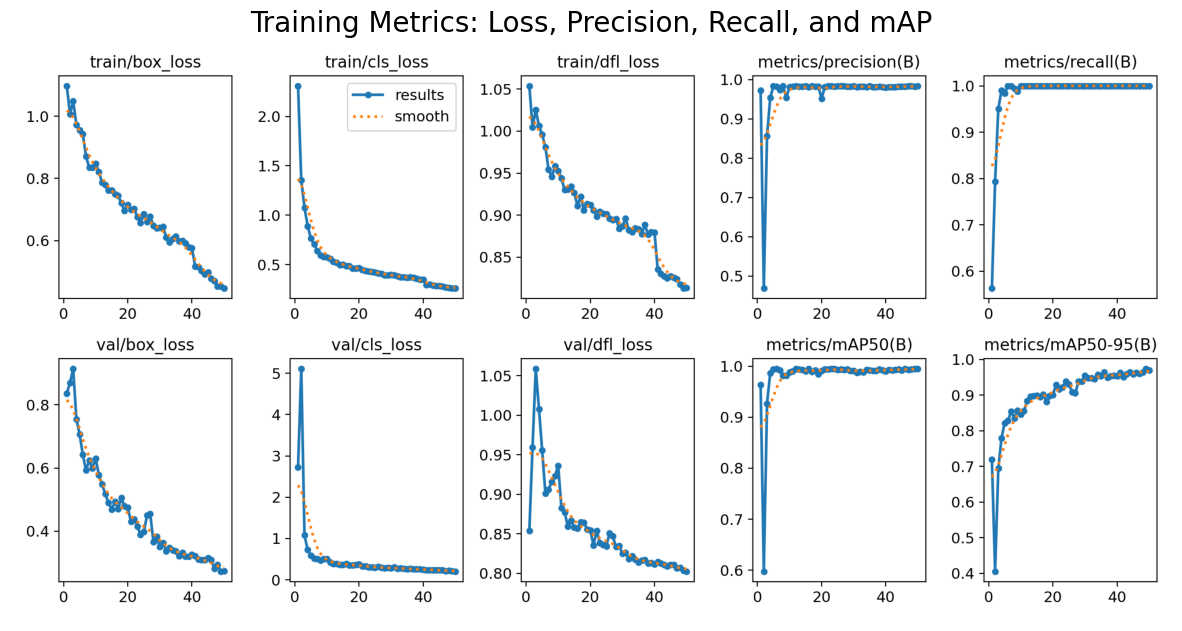

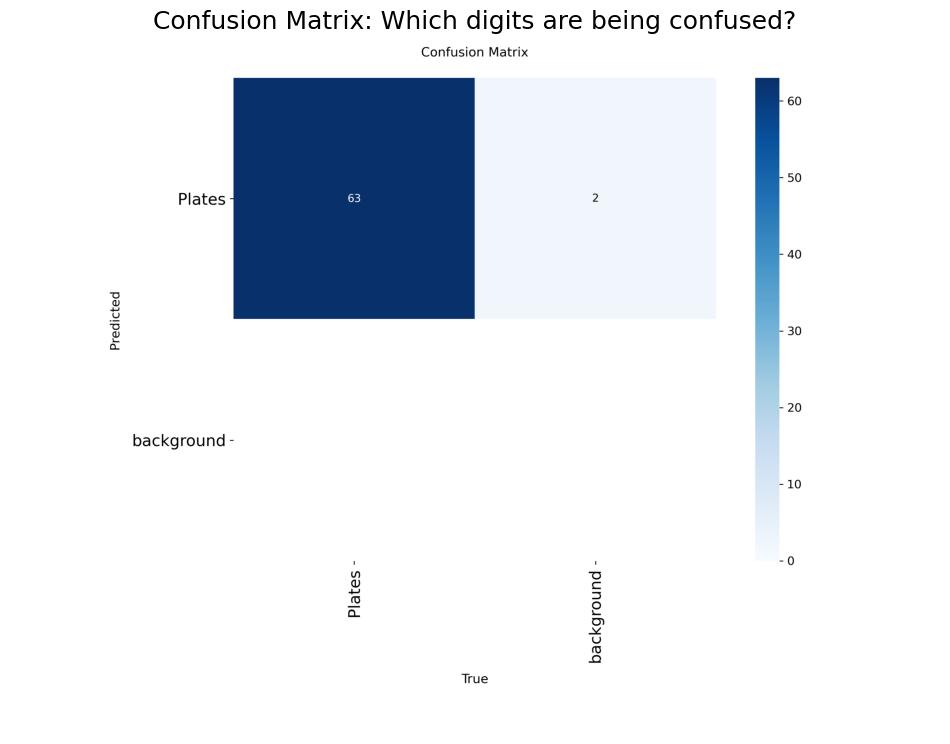

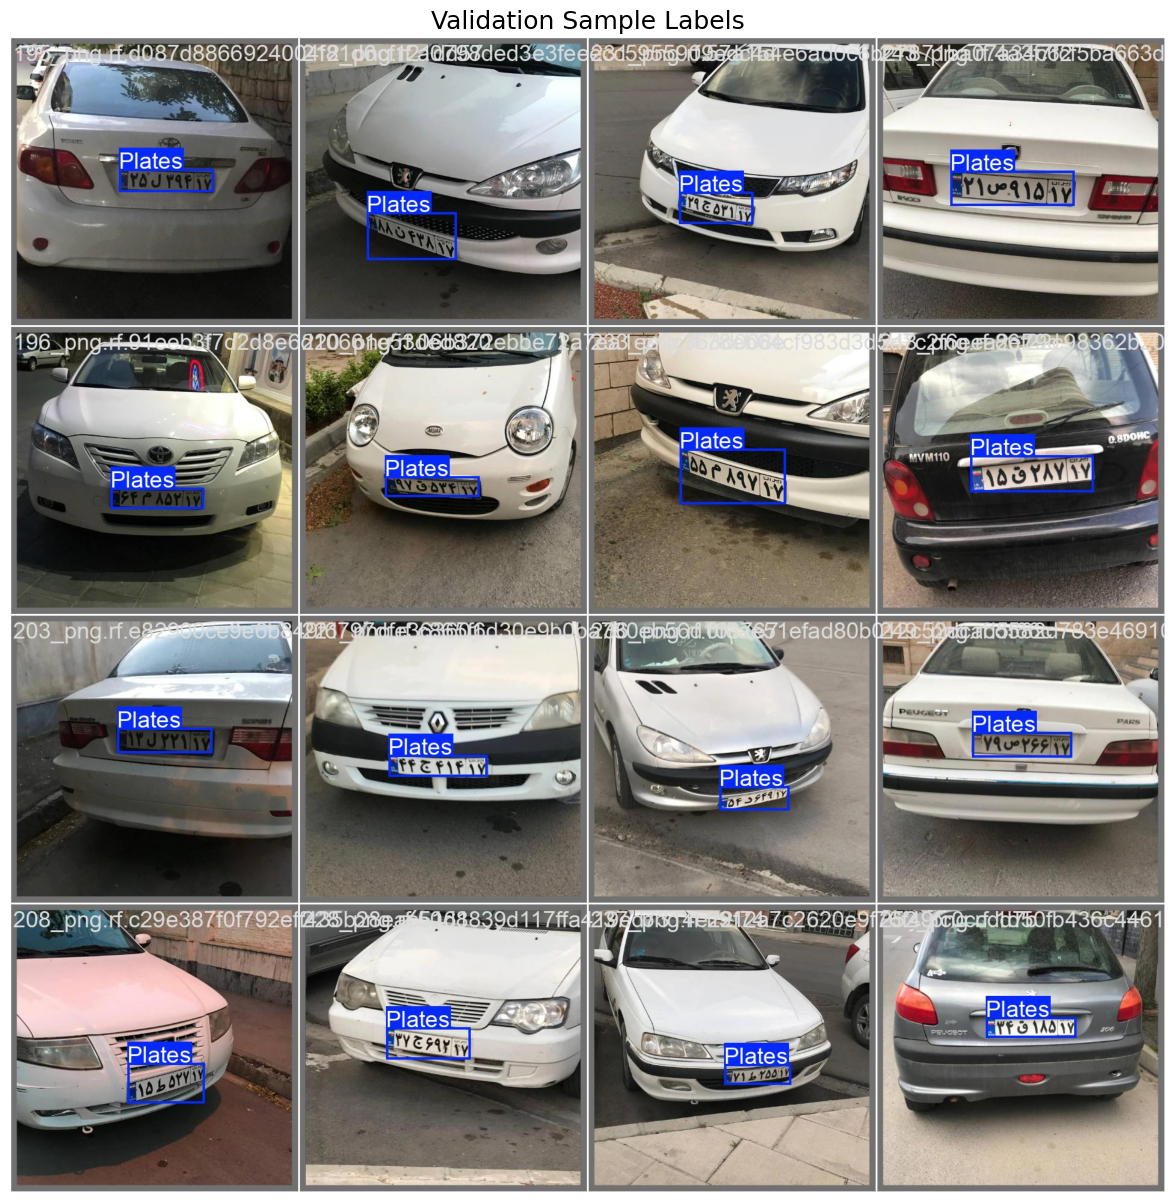

In [4]:
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# پیدا کردن مسیر نتایج آخرین آموزش
results_dir = '/kaggle/working/runs/detect/Persian_Digits_YOLO11' # نامی که در کد قبلی برای name انتخاب کردیم

# ۱. نمایش نمودار Loss و Accuracy (mAP)
results_png = os.path.join(results_dir, 'results.png')

if os.path.exists(results_png):
    plt.figure(figsize=(15, 10))
    img = mpimg.imread(results_png)
    plt.imshow(img)
    plt.axis('off')
    plt.title("Training Metrics: Loss, Precision, Recall, and mAP", fontsize=20)
    plt.show()
else:
    print("نمودار نتایج هنوز ساخته نشده است. مطمئن شوید آموزش تمام شده باشد.")

# ۲. نمایش ماتریس درهم‌ریختگی (Confusion Matrix)
# این نمودار نشان می‌دهد مدل کدام اعداد را با هم اشتباه می‌گیرد
confusion_matrix_png = os.path.join(results_dir, 'confusion_matrix.png')

if os.path.exists(confusion_matrix_png):
    plt.figure(figsize=(12, 10))
    img = mpimg.imread(confusion_matrix_png)
    plt.imshow(img)
    plt.axis('off')
    plt.title("Confusion Matrix: Which digits are being confused?", fontsize=18)
    plt.show()

# ۳. نمایش نمونه‌ای از عکس‌های اعتبارسنجی (Validation Batch)
val_batch_png = os.path.join(results_dir, 'val_batch0_labels.jpg')

if os.path.exists(val_batch_png):
    plt.figure(figsize=(15, 15))
    img = mpimg.imread(val_batch_png)
    plt.imshow(img)
    plt.axis('off')
    plt.title("Validation Sample Labels", fontsize=18)
    plt.show()